In [1]:
# on Iris flower dataset

In [5]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [14]:
iris = load_iris()

# X = pd.DataFrame(iris.data)
# X.columns = iris.feature_names
# y = iris.target
X = iris.data
y = iris.target # we dont need this here

In [15]:
X.shape

(150, 4)

<Axes: >

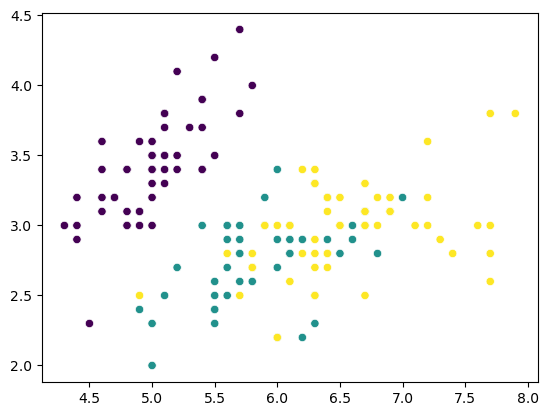

In [21]:
sns.scatterplot(x=X[:,0] , y=X[:,1] , c=y)# we are giving c=y , but actually we need to find this only,as we have the target value we are seeing this
# in the above line we are specifying the factor on each axis , we can change the feature e.g y = X[:,2], means based on 2nd feature

In [33]:
# first we will scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
# optional - dimensionality reduction using PCA (we will learn this later)

from sklearn.decomposition import PCA
pca = PCA(n_components =2) # it means we need to sclaed it down to 2 features 
pca_data = pca.fit_transform(X_scaled)

In [45]:
# Elbow menthod to find optimal K
wcss = []
for k in range (1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

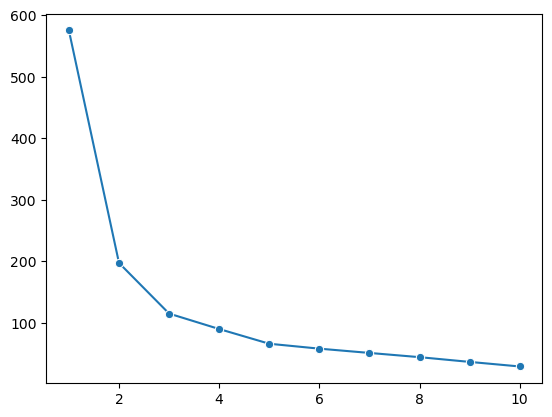

In [46]:
sns.lineplot(x=range(1,11), y= wcss, marker="o")

<Axes: >

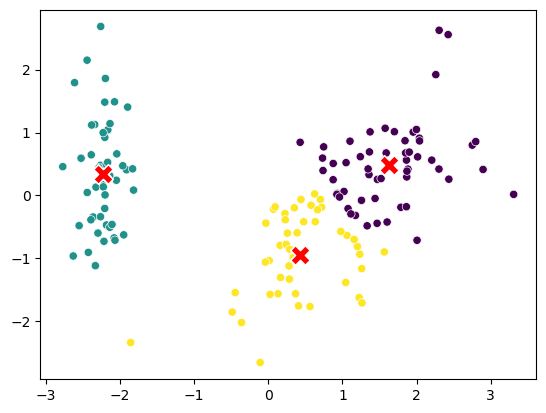

In [55]:
# Kmeans

kmeans = KMeans(n_clusters=3 , random_state = 10) # we give random state so that we get the same data all time , or it may be visulaised differently
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=psc_data[:,0], y=pca_data[:,1] ,c=labels) # after dimensionality reduction
# marking the centeroids
sns.scatterplot(x=kmeans.cluster_centers_[:,0] , y=kmeans.cluster_centers_[:,1], marker="X",c="red" , s=200)